# Multi-Target Fitting

In [1]:
import astropy.units as u
import jax.numpy as jnp
import numpy as np
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time

import nyx
from nyx import (
    Airglow,
    EffectiveApertureInstrument,
    Geometry,
    Moon,
    MultiTargetFit,
    Observation,
    Optimizer,
    Scene,
    SingleScattering,
    Stars,
    ZodiacalLight,
    freeze_all,
    unfreeze,
)

nyx.configure()

JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


## Building model:

In [2]:
geo = Geometry(
    wvls=jnp.linspace(300, 700, 50) * u.nm,
    nside=16,
    ngrid=2,
    fov=3.5 * u.deg,
)

instrument = EffectiveApertureInstrument.from_iactrace_table(geo, "CT1_aperture.npz")

atmosphere = SingleScattering.from_hg(geo)

sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
}

## Creating observations for two different targets

In [3]:
location = EarthLocation.from_geodetic(
    lon=16.50091 * u.deg,
    lat=-23.27153 * u.deg,
    height=1.835 * u.km,
)

# Field A: galactic center, 20 observations over 24 minutes
times_A = Time("2021-06-12T02:12:16", scale="utc") + jnp.linspace(0, 24, 20) * 60 * u.s
target_A = SkyCoord(l=0 * u.deg, b=0 * u.deg, frame="galactic")
obs_A = Observation(location, times_A, target_A, geo)

# Field B: offset field, 16 observations over 12 minutes
times_B = Time("2021-06-12T02:30:00", scale="utc") + jnp.linspace(0, 12, 16) * 60 * u.s
target_B = SkyCoord(l=10 * u.deg, b=5 * u.deg, frame="galactic")
obs_B = Observation(location, times_B, target_B, geo)

## Building scenes and creating synthetic data

We build a Scene per target, then apply a known efficiency and per-pixel flatfield to generate synthetic observations. The goal is to recover these shared instrument parameters from the joint fit.

In [4]:
scene_A = Scene.build(instrument, atmosphere, sources, obs_A)
scene_B = Scene.build(instrument, atmosphere, sources, obs_B)

# True shared instrument parameters
true_efficiency = 0.85
true_flatfield = np.random.lognormal(
    mean=0,
    sigma=0.1,
    size=instrument.pixel_efficiency.value.shape,
)

# Per-target pointing offsets
nshift_A = np.deg2rad(np.random.uniform(-0.03, 0.03, size=(obs_A.nobs, 2)))
nshift_B = np.deg2rad(np.random.uniform(-0.03, 0.03, size=(obs_B.nobs, 2)))

# Build "truth" scenes with known parameters.
scene_A_true = (
    scene_A.set("instruments.instrument.efficiency", true_efficiency)
    .set("instruments.instrument.pixel_efficiency", jnp.array(true_flatfield))
    .set("instruments.instrument.shift", jnp.array(nshift_A))
)
scene_B_true = (
    scene_B.set("instruments.instrument.efficiency", true_efficiency)
    .set("instruments.instrument.pixel_efficiency", jnp.array(true_flatfield))
    .set("instruments.instrument.shift", jnp.array(nshift_B))
)

# Render truth and add log-normal noise
rel_error = 0.03
rates_A = scene_A_true.render()["instrument"]
rates_B = scene_B_true.render()["instrument"]

data_A = rates_A * np.random.lognormal(mean=0, sigma=rel_error, size=rates_A.shape)
data_B = rates_B * np.random.lognormal(mean=0, sigma=rel_error, size=rates_B.shape)

## Setting up the multi-target fit

We wrap the two clean (unperturbed) scenes into a `MultiTargetFit`. This automatically:
- Collects all instruments by name (here just `'instrument'`)
- Determines which fields are shared across targets (efficiency, pixel_efficiency) vs per-target (shift, rotation)

In [5]:
mtf = MultiTargetFit(
    {
        "field_A": scene_A,
        "field_B": scene_B,
    }
)

print(f"Targets:     {mtf.target_names}")
print(f"Instruments: {mtf.instrument_names}")

Targets:     ('field_A', 'field_B')
Instruments: ('instrument',)


## Joint optimization

In [6]:
%%time
import optimistix as optx

# Start fully frozen and selectively unfreeze the fitted parameters.
mtf = freeze_all(mtf)

# Unfreeze shared efficiencies
mtf = unfreeze(
    mtf,
    lambda m: m.canonical_instruments["instrument"].efficiency,
    lambda m: m.canonical_instruments["instrument"].pixel_efficiency,
)

# Unfreeze per-obs parameters
for t in mtf.target_names:
    mtf = unfreeze(
        mtf,
        lambda m, t=t: m.target_scenes[t].instruments["instrument"].shift,
        lambda m, t=t: m.target_scenes[t].instruments["instrument"].rotation,
    )

# Observed data keyed by target name.
data = {"field_A": data_A, "field_B": data_B}


def residuals_fn(mtf):
    preds = mtf.render()
    return {t: (preds[t]["instrument"] - data[t]) / (data[t] * rel_error) for t in data}


opt = Optimizer(residuals_fn, optx.LBFGS(rtol=1e-6, atol=1e-6))
fitted, sol = opt.run(mtf, max_steps=1024)

n_total = obs_A.nobs + obs_B.nobs
chi2 = sum(jnp.sum(r**2) for r in residuals_fn(fitted).values())
print(
    f"chi2 / nobs = {chi2 / n_total:.2f}  "
    f"result = {sol.result}  "
    f"steps = {int(sol.stats['num_steps'])}"
)

chi2 / nobs = 933.34  result = optimistix._solution.RESULTS<>  steps = 385
CPU times: user 44.5 s, sys: 2.36 s, total: 46.8 s
Wall time: 18.5 s


## Determining errors:
For the multi-target case, the residuals are concatenated across all targets and instruments. 

In [7]:
%%time
errors = opt.errors(fitted, batch_size=8)

/home/hpc/b129dc/b129dc13/ECAP/nyx/nyx/infer/optimizer.py:356: NyxWarning: J is rank-deficient (1 of 1069 singular value(s) <= rcond * sigma_max, rcond = 1.274e-04; condition number of the retained block 3.700e+02).  The unconstrained direction(s) lie mostly along canonical_instruments.instrument.pixel_efficiency (100%).
  return parameter_errors(


CPU times: user 40.4 s, sys: 1.33 s, total: 41.8 s
Wall time: 21.9 s


## Results

efficiency: true=0.850  fit=0.855 ± 0.000


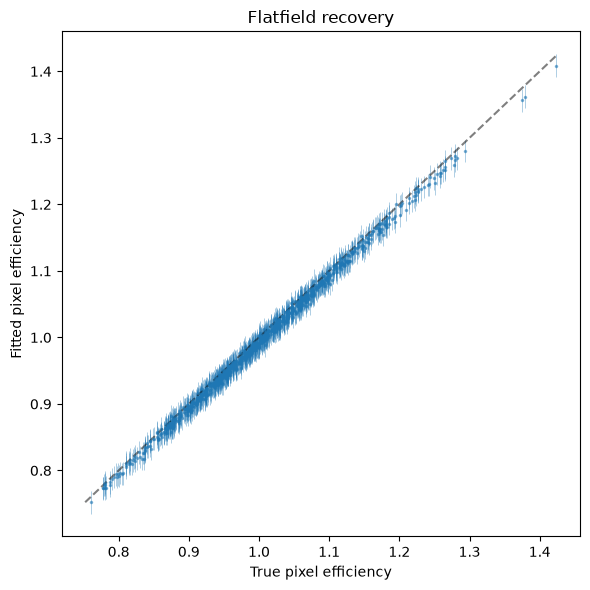

In [8]:
import matplotlib.pyplot as plt

# Flatfield recovery
fitted_ff = np.array(fitted.canonical_instruments["instrument"].pixel_efficiency.value)
ff_err = np.array(errors.canonical_instruments["instrument"].pixel_efficiency.value)

fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(true_flatfield, fitted_ff, yerr=0.017, fmt=".", ms=3, alpha=0.5, elinewidth=0.5)
lims = [min(true_flatfield.min(), fitted_ff.min()), max(true_flatfield.max(), fitted_ff.max())]
ax.plot(lims, lims, "k--", alpha=0.5)
ax.set_xlabel("True pixel efficiency")
ax.set_ylabel("Fitted pixel efficiency")
ax.set_title("Flatfield recovery")

# Shared efficiency
fitted_eff = float(fitted.canonical_instruments["instrument"].efficiency.value)
eff_err = float(errors.canonical_instruments["instrument"].efficiency.value)
print(f"efficiency: true={true_efficiency:.3f}  fit={fitted_eff:.3f} ± {eff_err:.3f}")

plt.tight_layout()
plt.show()

## Pointing recovery per target

The pointing offsets (`shift`) are fitted independently for each target. We can compare the fitted values against the true pointing offsets we injected:

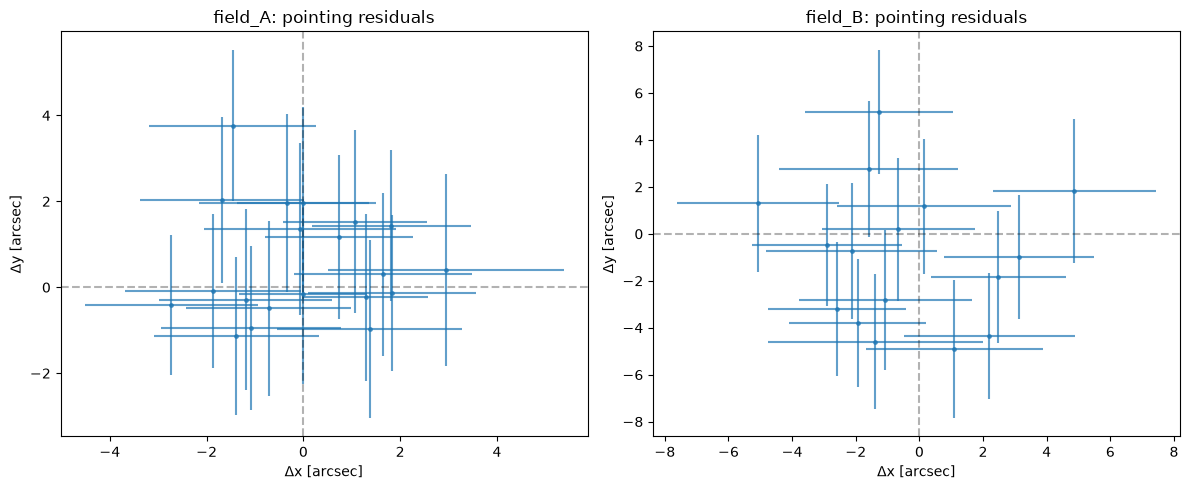

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, tname, true_shift in zip(axes, ["field_A", "field_B"], [nshift_A, nshift_B], strict=False):
    fitted_shift = np.array(fitted.target_scenes[tname].instruments["instrument"].shift.value)
    shift_err = np.array(errors.target_scenes[tname].instruments["instrument"].shift.value)

    residual_x = (np.rad2deg(fitted_shift[:, 0]) - np.rad2deg(true_shift[:, 0])) * 3600
    residual_y = (np.rad2deg(fitted_shift[:, 1]) - np.rad2deg(true_shift[:, 1])) * 3600
    err_x = np.rad2deg(shift_err[:, 0]) * 3600
    err_y = np.rad2deg(shift_err[:, 1]) * 3600

    ax.errorbar(residual_x, residual_y, xerr=err_x, yerr=err_y, fmt=".", ms=5, alpha=0.7)
    ax.axhline(0, color="k", ls="--", alpha=0.3)
    ax.axvline(0, color="k", ls="--", alpha=0.3)
    ax.set_xlabel(r"$\Delta$x [arcsec]")
    ax.set_ylabel(r"$\Delta$y [arcsec]")
    ax.set_title(f"{tname}: pointing residuals")

plt.tight_layout()
plt.show()